# Credit Risk Modelling

## 1. EDA

In [1]:
import pandas as pd
import numpy as np
import sklearn
import seaborn as sns
import matplotlib.pyplot as plt

In [20]:
df = pd.read_csv('german_credit_data.csv') 
df

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad
...,...,...,...,...,...,...,...,...,...,...,...
995,995,31,female,1,own,little,NaN,1736,12,furniture/equipment,good
996,996,40,male,3,own,little,little,3857,30,car,good
997,997,38,male,2,own,little,NaN,804,12,radio/TV,good
998,998,23,male,2,free,little,little,1845,45,radio/TV,bad


**Data Description**:
- **Age** — numeric  
- **Sex** — text: *male*, *female*  
- **Job** — numeric:  
  - 0 — unskilled and non-resident  
  - 1 — unskilled and resident  
  - 2 — skilled  
  - 3 — highly skilled  
- **Housing** — text: *own*, *rent*, *free*  
- **Saving accounts** — text: *little*, *moderate*, *quite rich*, *rich*  
- **Checking account** — numeric (in DM — Deutsch Mark)  
- **Credit amount** — numeric (in DM)  
- **Duration** — numeric (in month)  
- **Purpose** — text: *car*, *furniture/equipment*, *radio/TV*, *domestic appliances*, *repairs*, *education*, *business*, *vacation/others*  


In [21]:
df.info()
df.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Unnamed: 0        1000 non-null   int64 
 1   Age               1000 non-null   int64 
 2   Sex               1000 non-null   object
 3   Job               1000 non-null   int64 
 4   Housing           1000 non-null   object
 5   Saving accounts   817 non-null    object
 6   Checking account  606 non-null    object
 7   Credit amount     1000 non-null   int64 
 8   Duration          1000 non-null   int64 
 9   Purpose           1000 non-null   object
 10  Risk              1000 non-null   object
dtypes: int64(5), object(6)
memory usage: 86.1+ KB


,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
count,1000.000000,1000.000000,1000,1000.000000,1000,817,606,1000.000000,1000.000000,1000,1000
unique,NaN,NaN,2,NaN,3,4,3,NaN,NaN,8,2
top,NaN,NaN,male,NaN,own,little,little,NaN,NaN,car,good
freq,NaN,NaN,690,NaN,713,603,274,NaN,NaN,337,700
mean,499.500000,35.546000,NaN,1.904000,NaN,NaN,NaN,3271.258000,20.903000,NaN,NaN
std,288.819436,11.375469,NaN,0.653614,NaN,NaN,NaN,2822.736876,12.058814,NaN,NaN
min,0.000000,19.000000,NaN,0.000000,NaN,NaN,NaN,250.000000,4.000000,NaN,NaN
25%,249.750000,27.000000,NaN,2.000000,NaN,NaN,NaN,1365.500000,12.000000,NaN,NaN
50%,499.500000,33.000000,NaN,2.000000,NaN,NaN,NaN,2319.500000,18.000000,NaN,NaN
75%,749.250000,42.000000,NaN,2.000000,NaN,NaN,NaN,3972.250000,24.000000,NaN,NaN


In [22]:
# Change the Risk Column into binary (0 = good, 1 = bad)
df['Risk_binary'] = df['Risk'].map({'good': 0, 'bad': 1})
df['Risk_binary']

0      0
1      1
2      0
3      0
4      1
      ..
995    0
996    0
997    0
998    1
999    0
Name: Risk_binary, Length: 1000, dtype: int64

In [23]:
df

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk,Risk_binary
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good,0
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad,1
2,2,49,male,1,own,little,NaN,2096,12,education,good,0
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good,0
4,4,53,male,2,free,little,little,4870,24,car,bad,1
...,...,...,...,...,...,...,...,...,...,...,...,...
995,995,31,female,1,own,little,NaN,1736,12,furniture/equipment,good,0
996,996,40,male,3,own,little,little,3857,30,car,good,0
997,997,38,male,2,own,little,NaN,804,12,radio/TV,good,0
998,998,23,male,2,free,little,little,1845,45,radio/TV,bad,1


In [24]:
df = df.drop(['Risk','Unnamed: 0'], axis=1)

In [25]:
df['Risk_binary'].value_counts(normalize=True)

Risk_binary
0    0.7
1    0.3
Name: proportion, dtype: float64

Text(0.5, 1.0, 'Loan Amount vs Default')

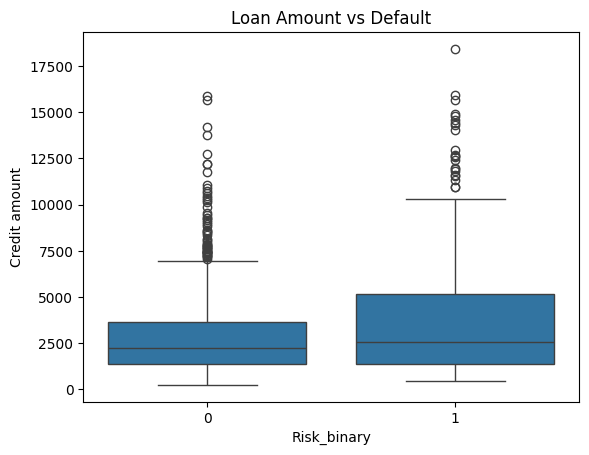

In [26]:
sns.boxplot(x='Risk_binary', y='Credit amount', data=df)
plt.title("Loan Amount vs Default")

## 2. Baseline Model: Logistic Regression

### -Model training

In [27]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report
from sklearn.metrics import roc_curve

In [28]:
# Define the target and featueres
X = df.drop(columns=['Risk_binary'])
y = df['Risk_binary']

In [29]:
# Differentiate between numeric and string features
numeric_features = X.select_dtypes(include=['int64']).columns #only int64 type for the numeric features
categorical_features = X.select_dtypes(include=['object']).columns
numeric_features, categorical_features

(Index(['Age', 'Job', 'Credit amount', 'Duration'], dtype='object'),
 Index(['Sex', 'Housing', 'Saving accounts', 'Checking account', 'Purpose'], dtype='object'))

> **Note:** In real credit risk models, *Sex* is excluded for regulatory reasons.  
> We keep it here only to improve model performance.


In [30]:
# Define the preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features), #standardizing -> numeric_features
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features) #onehotencoding -> categorical_features
    ]
)

In [34]:
# Build the Pipeline: Pipeline = preprocessing + model combined into one reproducible workflow
clf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=2000))
])

In [35]:
# Split the dataset into test set and training set 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
) #stratify=y -> guarantee the train/test split has the same class distribution as the original data

In [36]:
# Train the model
clf.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


### -Model evaluation

In [64]:
y_pred_proba = clf.predict_proba(X_test)[:, 1]
roc_auc_score(y_test, y_pred_proba)

0.7472619047619049

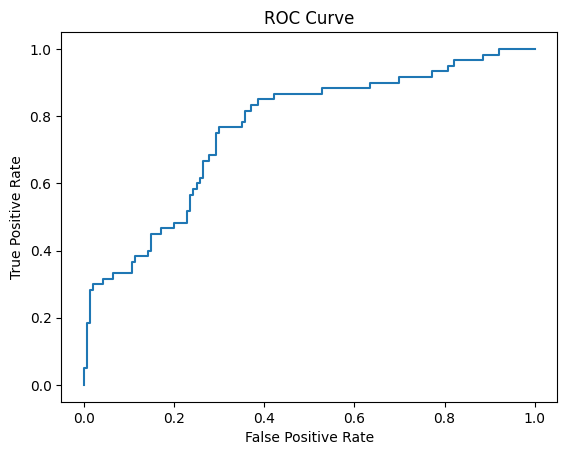

In [40]:
# Plot the ROC (Receiver Operating Characteristic) curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
plt.plot(fpr, tpr)
plt.title("ROC Curve") #->show the trade-off between FPR & TPR
plt.xlabel("False Positive Rate") #FPR(misclassifying good clients)
plt.ylabel("True Positive Rate") #TPR(catching bad clients)
plt.show() #the area under this curve is the AUC (Area Under Curve)

In [43]:
# Print the classification report
y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.77      0.89      0.83       140
           1       0.59      0.37      0.45        60

    accuracy                           0.73       200
   macro avg       0.68      0.63      0.64       200
weighted avg       0.72      0.73      0.71       200



### -Feature importance

In [56]:
# 1.Extract the trained logistic regression model and the preprocessor
logit_model = clf.named_steps['model']
preproc = clf.named_steps['preprocessor']

# 2. Get feature names after preprocessing
#    Numeric features
num_features = preproc.transformers_[0][2]  # Standardize

#    Categorical features 
cat_transformer = preproc.transformers_[1][1]  # OneHotEncoder 
cat_features_original = preproc.transformers_[1][2]  
cat_feature_names = cat_transformer.get_feature_names_out(cat_features_original)

# 3. Combine all feature names (numeric + one-hot encoded)
all_feature_names = np.concatenate([num_features, cat_feature_names])

# 4. Extract model coefficients (one coefficient per feature)
coefs = logit_model.coef_[0]

feature_importance = pd.DataFrame({
    'feature': all_feature_names,
    'coef': coefs
})

feature_importance['abs_coef'] = feature_importance['coef'].abs()
feature_importance.sort_values('abs_coef', ascending=False).head(20)

,feature,coef,abs_coef
17,Checking account_nan,-0.981406,0.981406
21,Purpose_education,0.697973,0.697973
14,Checking account_little,0.662009,0.662009
12,Saving accounts_rich,-0.562486,0.562486
9,Saving accounts_little,0.520060,0.520060
25,Purpose_vacation/others,-0.514369,0.514369
3,Duration,0.460203,0.460203
10,Saving accounts_moderate,0.447642,0.447642
13,Saving accounts_nan,-0.410411,0.410411
24,Purpose_repairs,0.394877,0.394877


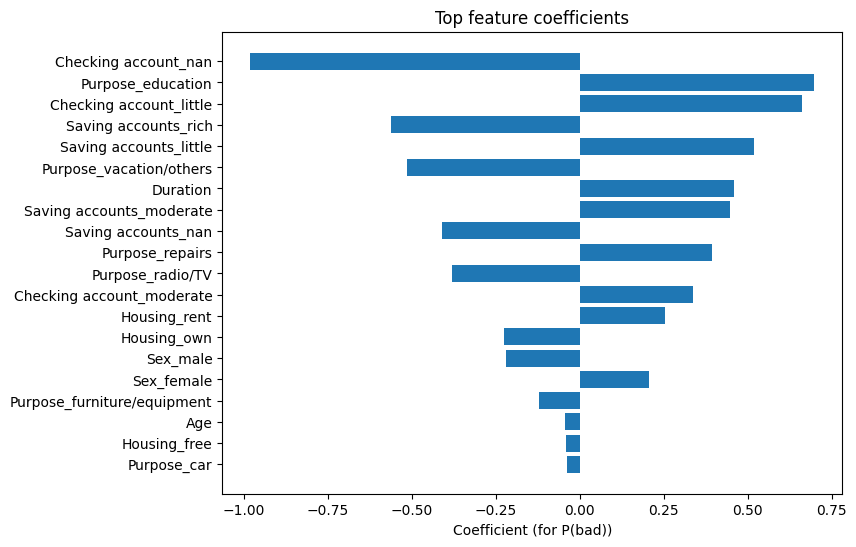

In [59]:
top_features = feature_importance.sort_values('abs_coef', ascending=False).head(20)

plt.figure(figsize=(8, 6))
plt.barh(top_features['feature'], top_features['coef'])
plt.xlabel('Coefficient (for P(bad))')
plt.title('Top feature coefficients')
plt.gca().invert_yaxis()
plt.show()

## 3. PD Segmentation (Model Calibration)

In [45]:
# Prepare a dataframe
results = pd.DataFrame({
    'y_true': y_test.values,   #1 = bad (default), 0 = good                  
    'pd_hat': y_pred_proba     #model output P(bad) = PD               
})

# Bucket the predicted PD into 5 quantile-based risk bands (0 = lowest risk, 4 = highest risk)
results['pd_bucket'] = pd.qcut(results['pd_hat'], q=5, labels=False)  

# Summarize statistics for each PD bucket
pd_segment = results.groupby('pd_bucket').agg(
    n_obs=('y_true', 'size'),
    avg_pd=('pd_hat', 'mean'),
    default_rate=('y_true', 'mean')
).reset_index()

pd_segment

,pd_bucket,n_obs,avg_pd,default_rate
0,0,40,0.072772,0.125
1,1,40,0.149070,0.075
2,2,40,0.250852,0.275
3,3,40,0.412666,0.450
4,4,40,0.622647,0.575


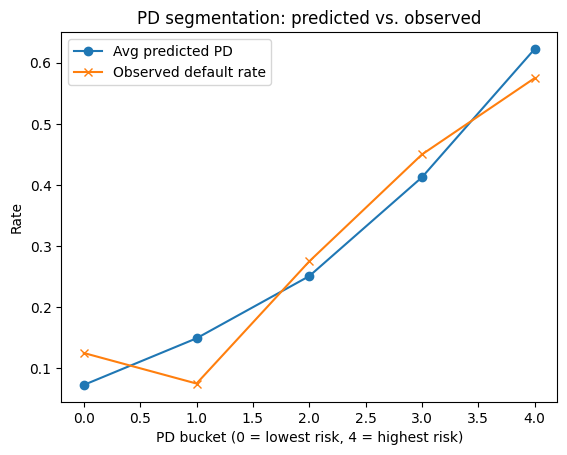

In [47]:
plt.figure()
plt.plot(pd_segment['pd_bucket'], pd_segment['avg_pd'], marker='o', label='Avg predicted PD')
plt.plot(pd_segment['pd_bucket'], pd_segment['default_rate'], marker='x', label='Observed default rate')
plt.xlabel('PD bucket (0 = lowest risk, 4 = highest risk)')
plt.ylabel('Rate')
plt.title('PD segmentation: predicted vs. observed')
plt.legend()
plt.show()

## 4. Stress Testing

In [55]:
# Baseline scenario: average PD of the current test set
baseline_pd = results['pd_hat'].mean()
print(f"Baseline average PD (test set): {baseline_pd:.4f}")

# Create a stress scenario: Assume the economy gets worse, 'Credit amount' increase by 20%
X_test_stress = X_test.copy()
X_test_stress['Credit amount'] = X_test_stress['Credit amount'] * 1.2

# Re-predict PDs under this stress scenario
y_pred_proba_stress = clf.predict_proba(X_test_stress)[:, 1]  
pd_hat_stress = y_pred_proba_stress
stress_pd = pd_hat_stress.mean()

print(f"Stress scenario average PD (+20% credit amount): {stress_pd:.4f}")
print(f"ΔPD (stress - baseline): {stress_pd - baseline_pd:.4f}")

Baseline average PD (test set): 0.3016
Stress scenario average PD (+20% credit amount): 0.3030
ΔPD (stress - baseline): 0.0014


> Increasing the **Credit amount by 20%** leads to only a **very small rise (+0.14%)**  in the portfolio’s average PD.

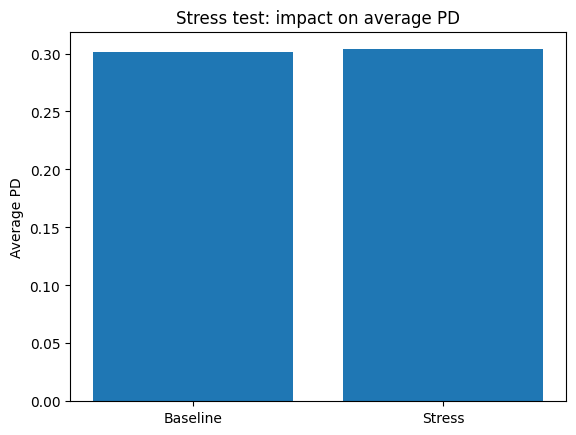

In [54]:
plt.bar(['Baseline', 'Stress'], [baseline_pd, stress_pd])
plt.ylabel('Average PD')
plt.title('Stress test: impact on average PD')
plt.show()

## 5. Model Benchmarking: Random Forest & Gradient Boosting

In [60]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

In [61]:
# Build three piplines
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        random_state=42
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=300,
        learning_rate=0.05,
        random_state=42
    )
}

In [62]:
auc_results = {}

for name, model in models.items():
    clf = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    
    clf.fit(X_train, y_train)
    y_pred_proba = clf.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_pred_proba)
    
    auc_results[name] = auc
    print(f"{name} AUC = {auc:.4f}")

Logistic Regression AUC = 0.7611
Random Forest AUC = 0.7686
Gradient Boosting AUC = 0.7473


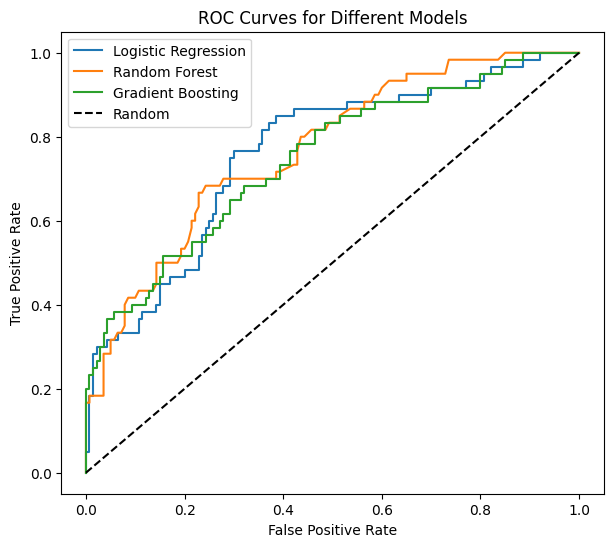

In [63]:
plt.figure(figsize=(7, 6))

for name, model in models.items():
    clf = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    clf.fit(X_train, y_train)
    y_pred_proba = clf.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    plt.plot(fpr, tpr, label=f"{name}")

plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for Different Models")
plt.legend()
plt.show()

In [1]:
## 5. Model Benchmarking: Random Forest & Gradient Boosting
   - Model training
   - AUC comparison
   - Feature importance (RF/GBM)

## 6. Model Comparison Summary
   - Table of AUC / Accuracy / Feature Importance
   - Reason why LR is still preferred (regulatory)

## 7. Conclusion
🎯 这样改后的优势
✔ 更符合银行/风控部门的文档标准（MDR、Model Validation Report）
✔ 让读者立即理解你做了 建模 → 校准 → 压力测试 → 对比 → 总结 的完整流程
✔ 面试官能一眼看到你理解了 Model Evaluation / Model Validation
✔ Stress Test 和 PD segmentation 不会显得奇怪或 misplaced
✔ Logistic Regression 看起来更像 baseline，而不是整个 notebook 的中心
🔥 如果你想要，我可以帮你：
✔ 把你 notebook 的所有标题重新整理成完美 markdown
✔ 自动生成 Summary Table（LR vs RF vs GBM）
✔ 生成专业的 Conclusion（面试可直接引用）
✔ 给你写 GitHub README 模板，让你的 repo 看起来像硕士 thesis 级别
你想让我帮你全部排版成最终专业版本吗？














IndentationError: unexpected indent (1264648890.py, line 2)